# Time Series Classification

Binary classification on 7-channel physiological series (T=200).

**Methods:** KNN-Euclidean · KNN-Manhattan · KNN-DTW · Shapelets + XGBoost · MiniROCKET + Ridge · MiniROCKET + LightGBM

## 1 — Installs

In [1]:
# ============================================================
# CELL 1: Install / Upgrade Packages (run once, then restart kernel)
# ============================================================
import sys, subprocess

packages = [
    "numpy", "pandas", "scipy", "scikit-learn",
    "tslearn", "sktime==0.29.0", "lightgbm", "xgboost",
    "imbalanced-learn", "threadpoolctl"
]

for pkg in packages:
    print(f"Installing/upgrading {pkg}...")
    subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade", pkg, "--no-cache-dir"],
                   check=False)

print("\n✅ All packages reinstalled.")
print("👉 RESTART THE KERNEL NOW (Kernel → Restart), then run the next cell.")

Installing/upgrading numpy...
Installing/upgrading pandas...
Installing/upgrading scipy...
Installing/upgrading scikit-learn...
Installing/upgrading tslearn...
Installing/upgrading sktime==0.29.0...
Installing/upgrading lightgbm...
Installing/upgrading xgboost...
Installing/upgrading imbalanced-learn...
Installing/upgrading threadpoolctl...

✅ All packages reinstalled.
👉 RESTART THE KERNEL NOW (Kernel → Restart), then run the next cell.


## 2 — Imports

In [10]:
# ============================================================
# CELL 2: Imports (run after restart)
# ============================================================
import random
import warnings
import time

# Suppress the harmless threadpoolctl dlopen() error
warnings.filterwarnings("ignore", category=UserWarning, module="threadpoolctl")
warnings.filterwarnings("ignore")   # general ignore for clean output

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import RidgeClassifierCV
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                              f1_score, classification_report,
                              confusion_matrix, roc_auc_score)
from imblearn.over_sampling import RandomOverSampler
from sktime.transformations.panel.shapelet_transform import RandomShapeletTransform
from sktime.transformations.panel.rocket import MiniRocketMultivariate
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 110

print("All imports OK")
print(f"NumPy: {np.__version__}, Pandas: {pd.__version__}")

All imports OK
NumPy: 1.26.4, Pandas: 2.2.3


## 3 — Load Data

In [18]:
DATA_DIR = "."   # change if needed

X_train = np.load(f"{DATA_DIR}/X_train_raw.npy")
X_test  = np.load(f"{DATA_DIR}/X_test_raw.npy")
y_train = np.load(f"{DATA_DIR}/y_train.npy").astype(int)
y_test  = np.load(f"{DATA_DIR}/y_test.npy").astype(int)

N_TRAIN, T, C = X_train.shape
N_TEST = X_test.shape[0]

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")
print(f"Classes train: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Classes test : {dict(zip(*np.unique(y_test,  return_counts=True)))}")
print(f"Imbalance    : {np.bincount(y_train)[0]/np.bincount(y_train)[1]:.2f}:1")

Train : (3355, 200, 7)
Test  : (953, 200, 7)
Classes train: {0: 2192, 1: 1163}
Classes test : {0: 695, 1: 258}
Imbalance    : 1.88:1


## 4 — Exploratory Data Analysis

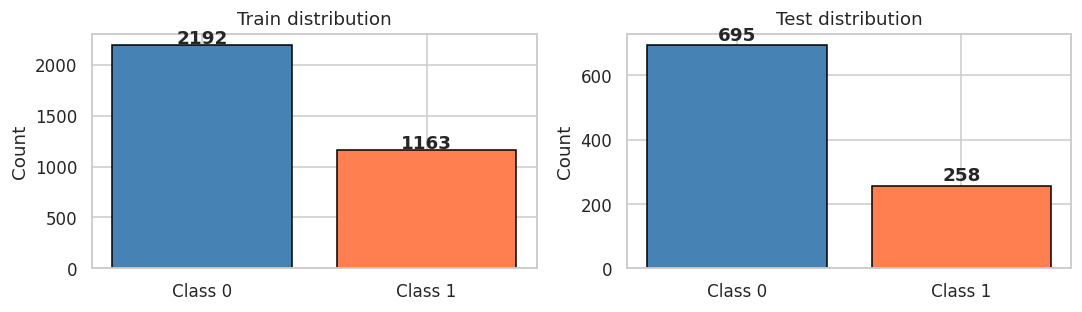

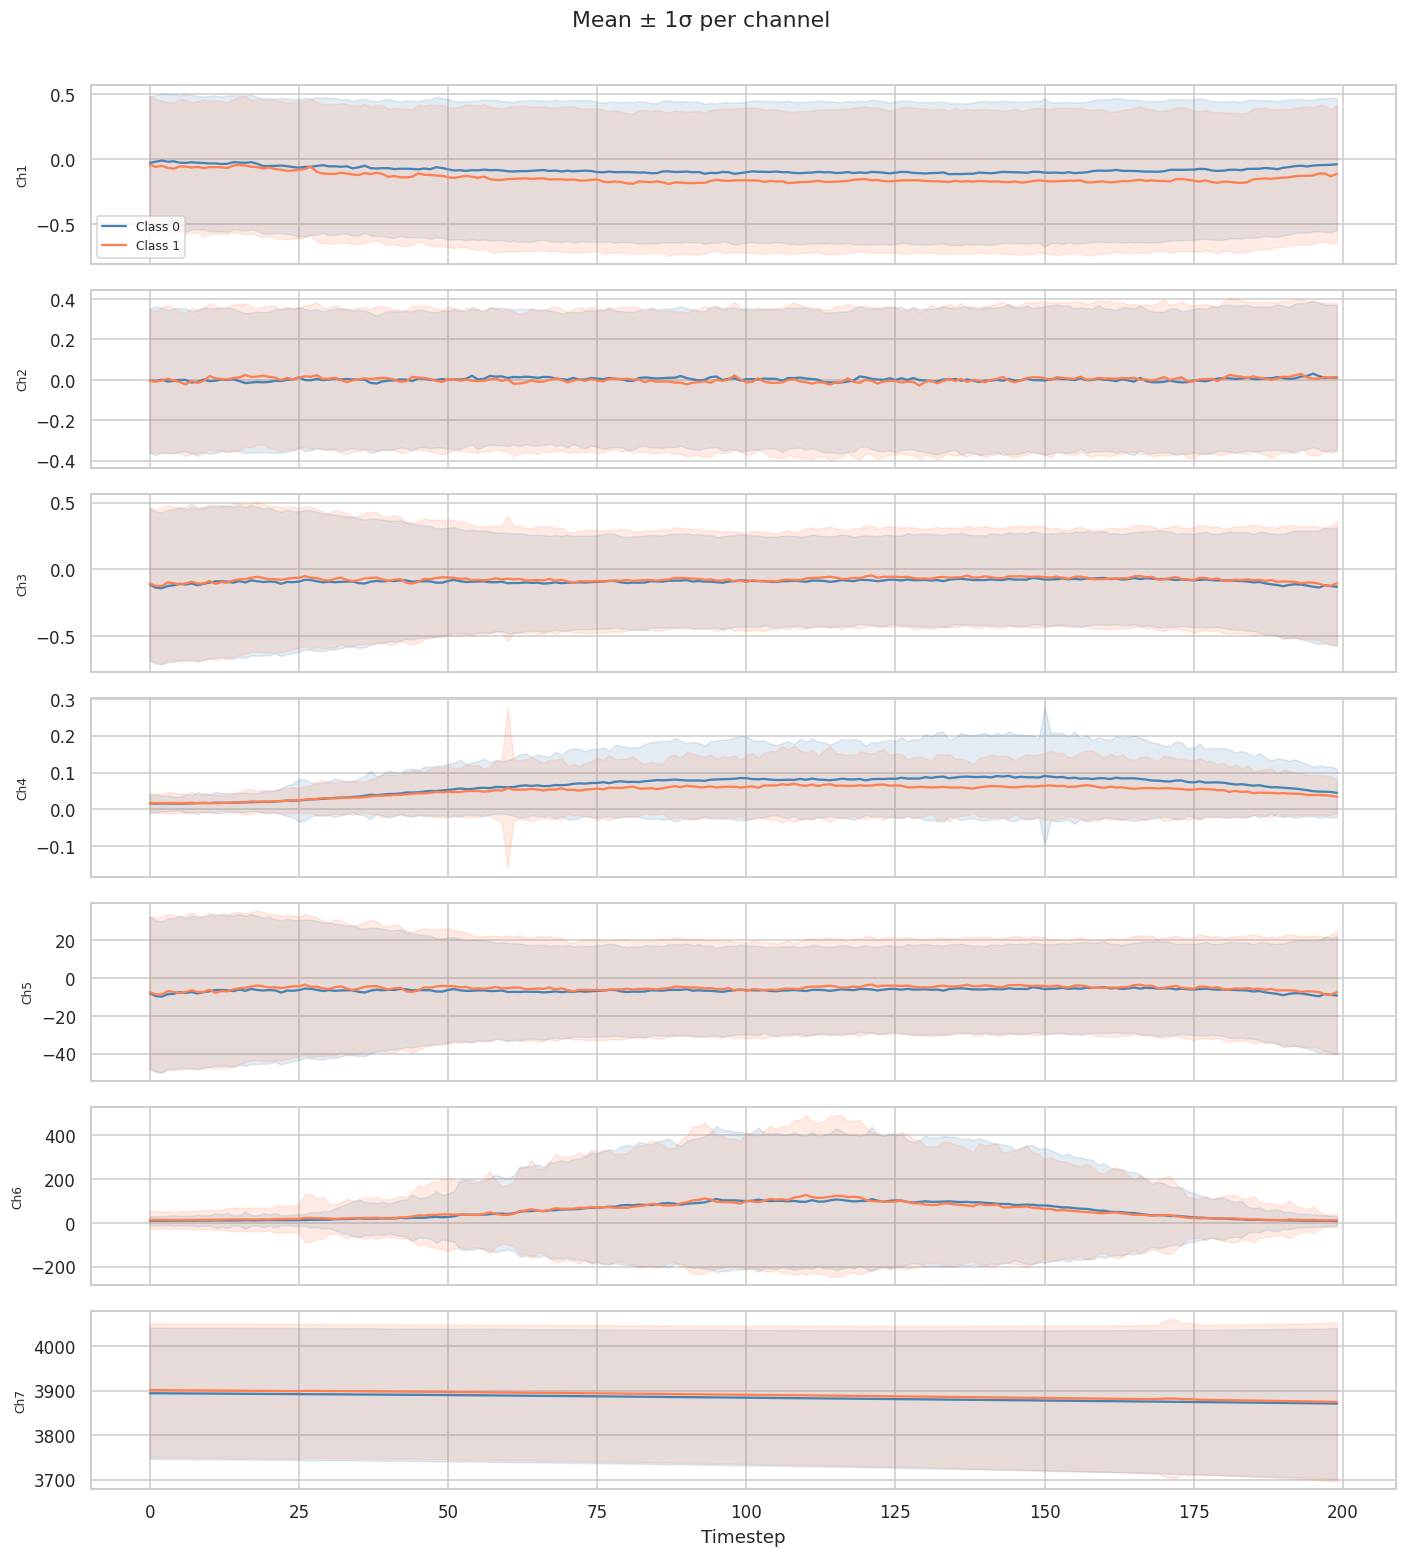

In [6]:
CH = [f"Ch{i+1}" for i in range(C)]

# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, y, title in zip(axes, [y_train, y_test], ["Train", "Test"]):
    counts = np.bincount(y)
    bars = ax.bar(["Class 0", "Class 1"], counts, color=["steelblue","coral"], edgecolor="k")
    for b, c in zip(bars, counts):
        ax.text(b.get_x()+b.get_width()/2, c+15, str(c), ha="center", fontweight="bold")
    ax.set_title(f"{title} distribution"); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

# Mean ± std per channel per class
fig, axes = plt.subplots(C, 1, figsize=(13, 2*C), sharex=True)
t = np.arange(T)
col = {0: "steelblue", 1: "coral"}
for ch, ax in enumerate(axes):
    for cls in [0, 1]:
        m = y_train == cls
        mu  = X_train[m, :, ch].mean(0)
        sig = X_train[m, :, ch].std(0)
        ax.plot(t, mu, color=col[cls], label=f"Class {cls}")
        ax.fill_between(t, mu-sig, mu+sig, color=col[cls], alpha=0.15)
    ax.set_ylabel(CH[ch], fontsize=8)
    if ch == 0: ax.legend(fontsize=8)
axes[-1].set_xlabel("Timestep")
fig.suptitle("Mean ± 1σ per channel", y=1.01); plt.tight_layout(); plt.show()

## 5 — Pre-processing  (z-normalise + derivative augmentation)

In [19]:
# Z-normalise each channel (fit on train only)
Xtr_z = np.zeros_like(X_train, dtype=np.float32)
Xte_z = np.zeros_like(X_test,  dtype=np.float32)
for ch in range(C):
    sc = StandardScaler()
    Xtr_z[:, :, ch] = sc.fit_transform(X_train[:, :, ch])
    Xte_z[:, :, ch] = sc.transform(X_test[:, :, ch])

# Add first-derivative channels (captures rate-of-change)
def add_deriv(X):
    dX = np.diff(X, axis=1, prepend=X[:, :1, :])
    return np.concatenate([X, dX], axis=2).astype(np.float32)

Xtr_feat = add_deriv(Xtr_z)   # (N, T, 2C)
Xte_feat = add_deriv(Xte_z)

# Flat versions for KNN
Xtr_flat = Xtr_feat.reshape(N_TRAIN, -1)
Xte_flat = Xte_feat.reshape(N_TEST,  -1)

print(f"Feature tensor : {Xtr_feat.shape}")
print(f"Flat shape     : {Xtr_flat.shape}")

Feature tensor : (3355, 200, 14)
Flat shape     : (3355, 2800)


## 6 — Evaluation Helper

In [8]:
RESULTS = []

def evaluate(name, y_true, y_pred, y_proba=None):
    acc = accuracy_score(y_true, y_pred)
    bal = balanced_accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro")
    auc = roc_auc_score(y_true, y_proba) if y_proba is not None else float("nan")

    print("=" * 55)
    print(f"  {name}")
    print("=" * 55)
    print(f"  Accuracy          {acc:.4f}")
    print(f"  Balanced Accuracy {bal:.4f}")
    print(f"  Macro F1          {f1:.4f}")
    if not np.isnan(auc): print(f"  ROC-AUC           {auc:.4f}")
    print()
    print(classification_report(y_true, y_pred,
                                 target_names=["Class 0","Class 1"]))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(3.5, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred 0","Pred 1"],
                yticklabels=["True 0","True 1"])
    plt.title(name, fontsize=9); plt.tight_layout(); plt.show()

    RESULTS.append({"Model": name, "Macro F1": f1,
                    "Bal Acc": bal, "ROC-AUC": auc})

print("evaluate() ready")

evaluate() ready


## 7 — KNN · Euclidean Distance

Best k=3  CV-F1=0.7393  [17s]
  KNN Euclidean
  Accuracy          0.5740
  Balanced Accuracy 0.5129
  Macro F1          0.5071

              precision    recall  f1-score   support

     Class 0       0.74      0.65      0.69       695
     Class 1       0.28      0.38      0.33       258

    accuracy                           0.57       953
   macro avg       0.51      0.51      0.51       953
weighted avg       0.61      0.57      0.59       953



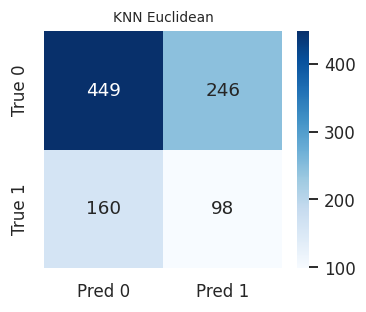

In [9]:
ros = RandomOverSampler(random_state=SEED)
Xr, yr = ros.fit_resample(Xtr_flat, y_train)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
gs = GridSearchCV(
    KNeighborsClassifier(metric="euclidean", weights="distance", n_jobs=-1),
    {"n_neighbors": [3, 5, 7, 9]},
    cv=cv5, scoring="f1_macro", n_jobs=1
)
t0 = time.time()
gs.fit(Xr, yr)
print(f"Best k={gs.best_params_['n_neighbors']}  CV-F1={gs.best_score_:.4f}  [{time.time()-t0:.0f}s]")

pred_euc = gs.best_estimator_.predict(Xte_flat)
evaluate("KNN Euclidean", y_test, pred_euc)

## 8 — KNN · Manhattan Distance

Best k=3  CV-F1=0.7521  [293s]
  KNN Manhattan
  Accuracy          0.5698
  Balanced Accuracy 0.5015
  Macro F1          0.4977

              precision    recall  f1-score   support

     Class 0       0.73      0.65      0.69       695
     Class 1       0.27      0.35      0.31       258

    accuracy                           0.57       953
   macro avg       0.50      0.50      0.50       953
weighted avg       0.61      0.57      0.58       953



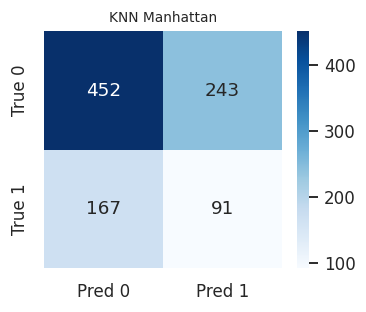

In [10]:
ros = RandomOverSampler(random_state=SEED)
Xr, yr = ros.fit_resample(Xtr_flat, y_train)

gs_man = GridSearchCV(
    KNeighborsClassifier(metric="manhattan", weights="distance", n_jobs=-1),
    {"n_neighbors": [3, 5, 7, 9]},
    cv=cv5, scoring="f1_macro", n_jobs=1
)
t0 = time.time()
gs_man.fit(Xr, yr)
print(f"Best k={gs_man.best_params_['n_neighbors']}  CV-F1={gs_man.best_score_:.4f}  [{time.time()-t0:.0f}s]")

pred_man = gs_man.best_estimator_.predict(Xte_flat)
evaluate("KNN Manhattan", y_test, pred_man)

## 9 — KNN · DTW Distance

Sakoe-Chiba band DTW on PAA-compressed sequences (200→40 timesteps).

In [11]:
from scipy.spatial.distance import cdist

def dtw_sakoe(x, y, radius=5):
    """Multivariate DTW with Sakoe-Chiba band.  x,y: (T,C)"""
    n, m = len(x), len(y)
    D = cdist(x, y, metric="euclidean")          # (T_x, T_y) cost matrix
    cost = np.full((n+1, m+1), np.inf)
    cost[0, 0] = 0.0
    for i in range(1, n+1):
        lo, hi = max(1, i-radius), min(m, i+radius)
        for j in range(lo, hi+1):
            cost[i,j] = D[i-1,j-1] + min(cost[i-1,j], cost[i,j-1], cost[i-1,j-1])
    return float(np.sqrt(cost[n, m]))

def paa(X, n_seg=40):
    """Piecewise Aggregate Approximation  (N,T,C) → (N,n_seg,C)"""
    N, T_len, ch = X.shape
    seg = T_len // n_seg
    out = np.zeros((N, n_seg, ch), dtype=np.float32)
    for i in range(n_seg):
        s = i*seg
        e = (i+1)*seg if i < n_seg-1 else T_len
        out[:, i, :] = X[:, s:e, :].mean(1)
    return out

# Compress 200 → 40 timesteps
Xtr_paa = paa(Xtr_feat, 40)
Xte_paa = paa(Xte_feat, 40)
print(f"PAA shapes — train: {Xtr_paa.shape}, test: {Xte_paa.shape}")

# Stratified subsample to keep DTW tractable
DTW_N = 1000
Xtr_dtw, _, ytr_dtw, _ = train_test_split(
    Xtr_paa, y_train, train_size=DTW_N, stratify=y_train, random_state=SEED
)
print(f"DTW subset: {Xtr_dtw.shape}")

PAA shapes — train: (3355, 40, 14), test: (953, 40, 14)
DTW subset: (1000, 40, 14)


### 9a — Precompute Distance Matrices

In [12]:
print(f"Computing {DTW_N}×{DTW_N} train matrix ...")
t0 = time.time()
D_train = np.zeros((DTW_N, DTW_N), dtype=np.float32)
for i in range(DTW_N):
    for j in range(i+1, DTW_N):
        d = dtw_sakoe(Xtr_dtw[i], Xtr_dtw[j])
        D_train[i,j] = D_train[j,i] = d
    if i % 100 == 0:
        print(f"  row {i}/{DTW_N}  {time.time()-t0:.0f}s")
print(f"Train matrix done in {time.time()-t0:.0f}s")

Computing 1000×1000 train matrix ...
  row 0/1000  1s
  row 100/1000  55s
  row 200/1000  104s
  row 300/1000  149s
  row 400/1000  187s
  row 500/1000  217s
  row 600/1000  243s
  row 700/1000  264s
  row 800/1000  278s
  row 900/1000  287s
Train matrix done in 290s


In [13]:
print(f"Computing {N_TEST}×{DTW_N} test matrix ...")
t0 = time.time()
D_test = np.zeros((N_TEST, DTW_N), dtype=np.float32)
for i in range(N_TEST):
    for j in range(DTW_N):
        D_test[i,j] = dtw_sakoe(Xte_paa[i], Xtr_dtw[j])
    if i % 100 == 0:
        print(f"  row {i}/{N_TEST}  {time.time()-t0:.0f}s")
print(f"Test matrix done in {time.time()-t0:.0f}s")

Computing 953×1000 test matrix ...
  row 0/953  1s
  row 100/953  57s
  row 200/953  116s
  row 300/953  173s
  row 400/953  230s
  row 500/953  289s
  row 600/953  346s
  row 700/953  404s
  row 800/953  463s
  row 900/953  522s
Test matrix done in 553s


### 9b — DTW KNN (precomputed)

  k=3  CV macro-F1=0.5556
  k=5  CV macro-F1=0.5211
  k=7  CV macro-F1=0.5164
Best k=3
  KNN DTW
  Accuracy          0.6663
  Balanced Accuracy 0.5421
  Macro F1          0.5430

              precision    recall  f1-score   support

     Class 0       0.75      0.81      0.78       695
     Class 1       0.35      0.27      0.31       258

    accuracy                           0.67       953
   macro avg       0.55      0.54      0.54       953
weighted avg       0.64      0.67      0.65       953



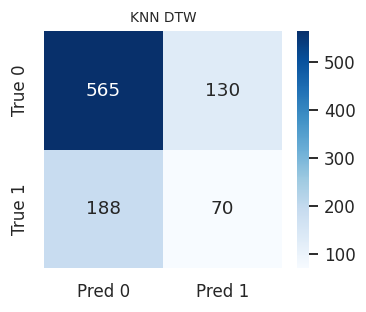

In [14]:
cv_dtw = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
best_k, best_f1 = 5, -1

for k in [3, 5, 7]:
    scores = []
    for tr_idx, val_idx in cv_dtw.split(D_train, ytr_dtw):
        knn = KNeighborsClassifier(n_neighbors=k, metric="precomputed", weights="distance")
        knn.fit(D_train[np.ix_(tr_idx, tr_idx)], ytr_dtw[tr_idx])
        p = knn.predict(D_train[np.ix_(val_idx, tr_idx)])
        scores.append(f1_score(ytr_dtw[val_idx], p, average="macro", zero_division=0))
    mean = np.mean(scores)
    print(f"  k={k}  CV macro-F1={mean:.4f}")
    if mean > best_f1: best_k, best_f1 = k, mean

print(f"Best k={best_k}")
knn_dtw = KNeighborsClassifier(n_neighbors=best_k, metric="precomputed", weights="distance")
knn_dtw.fit(D_train, ytr_dtw)
pred_dtw = knn_dtw.predict(D_test)
evaluate("KNN DTW", y_test, pred_dtw)

## 10 — Shapelets

sktime `RandomShapeletTransform` expects **(N, C, T)** — note axes are swapped vs our (N, T, C).

In [ ]:
# sktime input: (N, n_channels, T)
Xtr_sk = np.transpose(Xtr_feat, (0, 2, 1))   # (N_TRAIN, 2C, T)
Xte_sk = np.transpose(Xte_feat, (0, 2, 1))
print(f"sktime input shape: {Xtr_sk.shape}")

rst = RandomShapeletTransform(
    n_shapelet_samples = 2000,
    max_shapelets      = 50,
    min_shapelet_length = 15,
    max_shapelet_length = 80,
    random_state       = SEED,
    n_jobs             = -1
)
t0 = time.time()
Xtr_shape = rst.fit_transform(Xtr_sk, y_train)
Xte_shape = rst.transform(Xte_sk)
print(f"Shapelet features: {Xtr_shape.shape}   [{time.time()-t0:.0f}s]")

sktime input shape: (3355, 14, 200)
Shapelet features: (3355, 50)   [4097s]


### 10a — Shapelet Analysis

In sktime 0.29, each stored shapelet is a tuple:
`(quality, length, start_pos, channel, inst_idx, cls_idx, values_array)`

Total shapelets retained: 50

Top 10 by quality:
 rank  quality  length  start  channel  inst_idx  class
    1  0.01138      39    129        5       753      1
    2  0.01013      49    121        3         8      0
    3  0.00990      21    149        5      1282      0
    4  0.00974      55     77        3      1339      1
    5  0.00955      53    133        3       592      1
    6  0.00953      79      4        3      1640      0
    7  0.00912      55     97        3      1625      0
    8  0.00842      76     97        3      1804      0
    9  0.00833      29    122        5       834      0
   10  0.00820      42     92        3       202      1


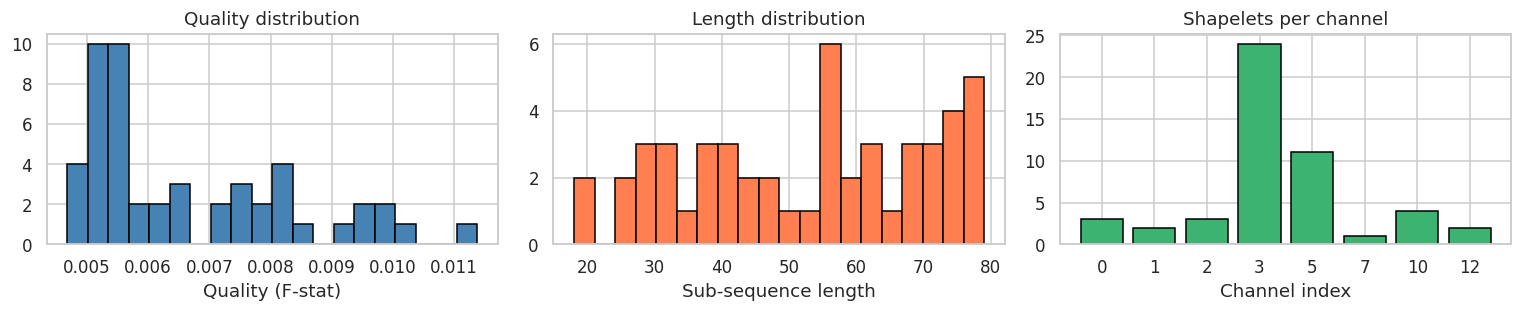

In [ ]:
shapelets = rst.shapelets   # list of 7-element tuples

# Build summary table
rows = []
for i, sh in enumerate(shapelets):
    rows.append({
        "rank"    : i+1,
        "quality" : round(float(sh[0]), 5),
        "length"  : int(sh[1]),
        "start"   : int(sh[2]),
        "channel" : int(sh[3]),
        "inst_idx": int(sh[4]),
        "class"   : int(sh[5]),
    })

df_sh = pd.DataFrame(rows)
print(f"Total shapelets retained: {len(shapelets)}")
print()
print("Top 10 by quality:")
print(df_sh.sort_values("quality", ascending=False).head(10).to_string(index=False))

# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 3))

axes[0].hist(df_sh["quality"], bins=20, color="steelblue", edgecolor="k")
axes[0].set_title("Quality distribution"); axes[0].set_xlabel("Quality (F-stat)")

axes[1].hist(df_sh["length"], bins=20, color="coral", edgecolor="k")
axes[1].set_title("Length distribution"); axes[1].set_xlabel("Sub-sequence length")

ch_counts = df_sh["channel"].value_counts().sort_index()
axes[2].bar(ch_counts.index.astype(str), ch_counts.values, color="mediumseagreen", edgecolor="k")
axes[2].set_title("Shapelets per channel"); axes[2].set_xlabel("Channel index")

plt.tight_layout(); plt.show()

### 10b — Visualise Top Shapelets

Each shapelet (black) is plotted at its discovered position over the class-mean background.

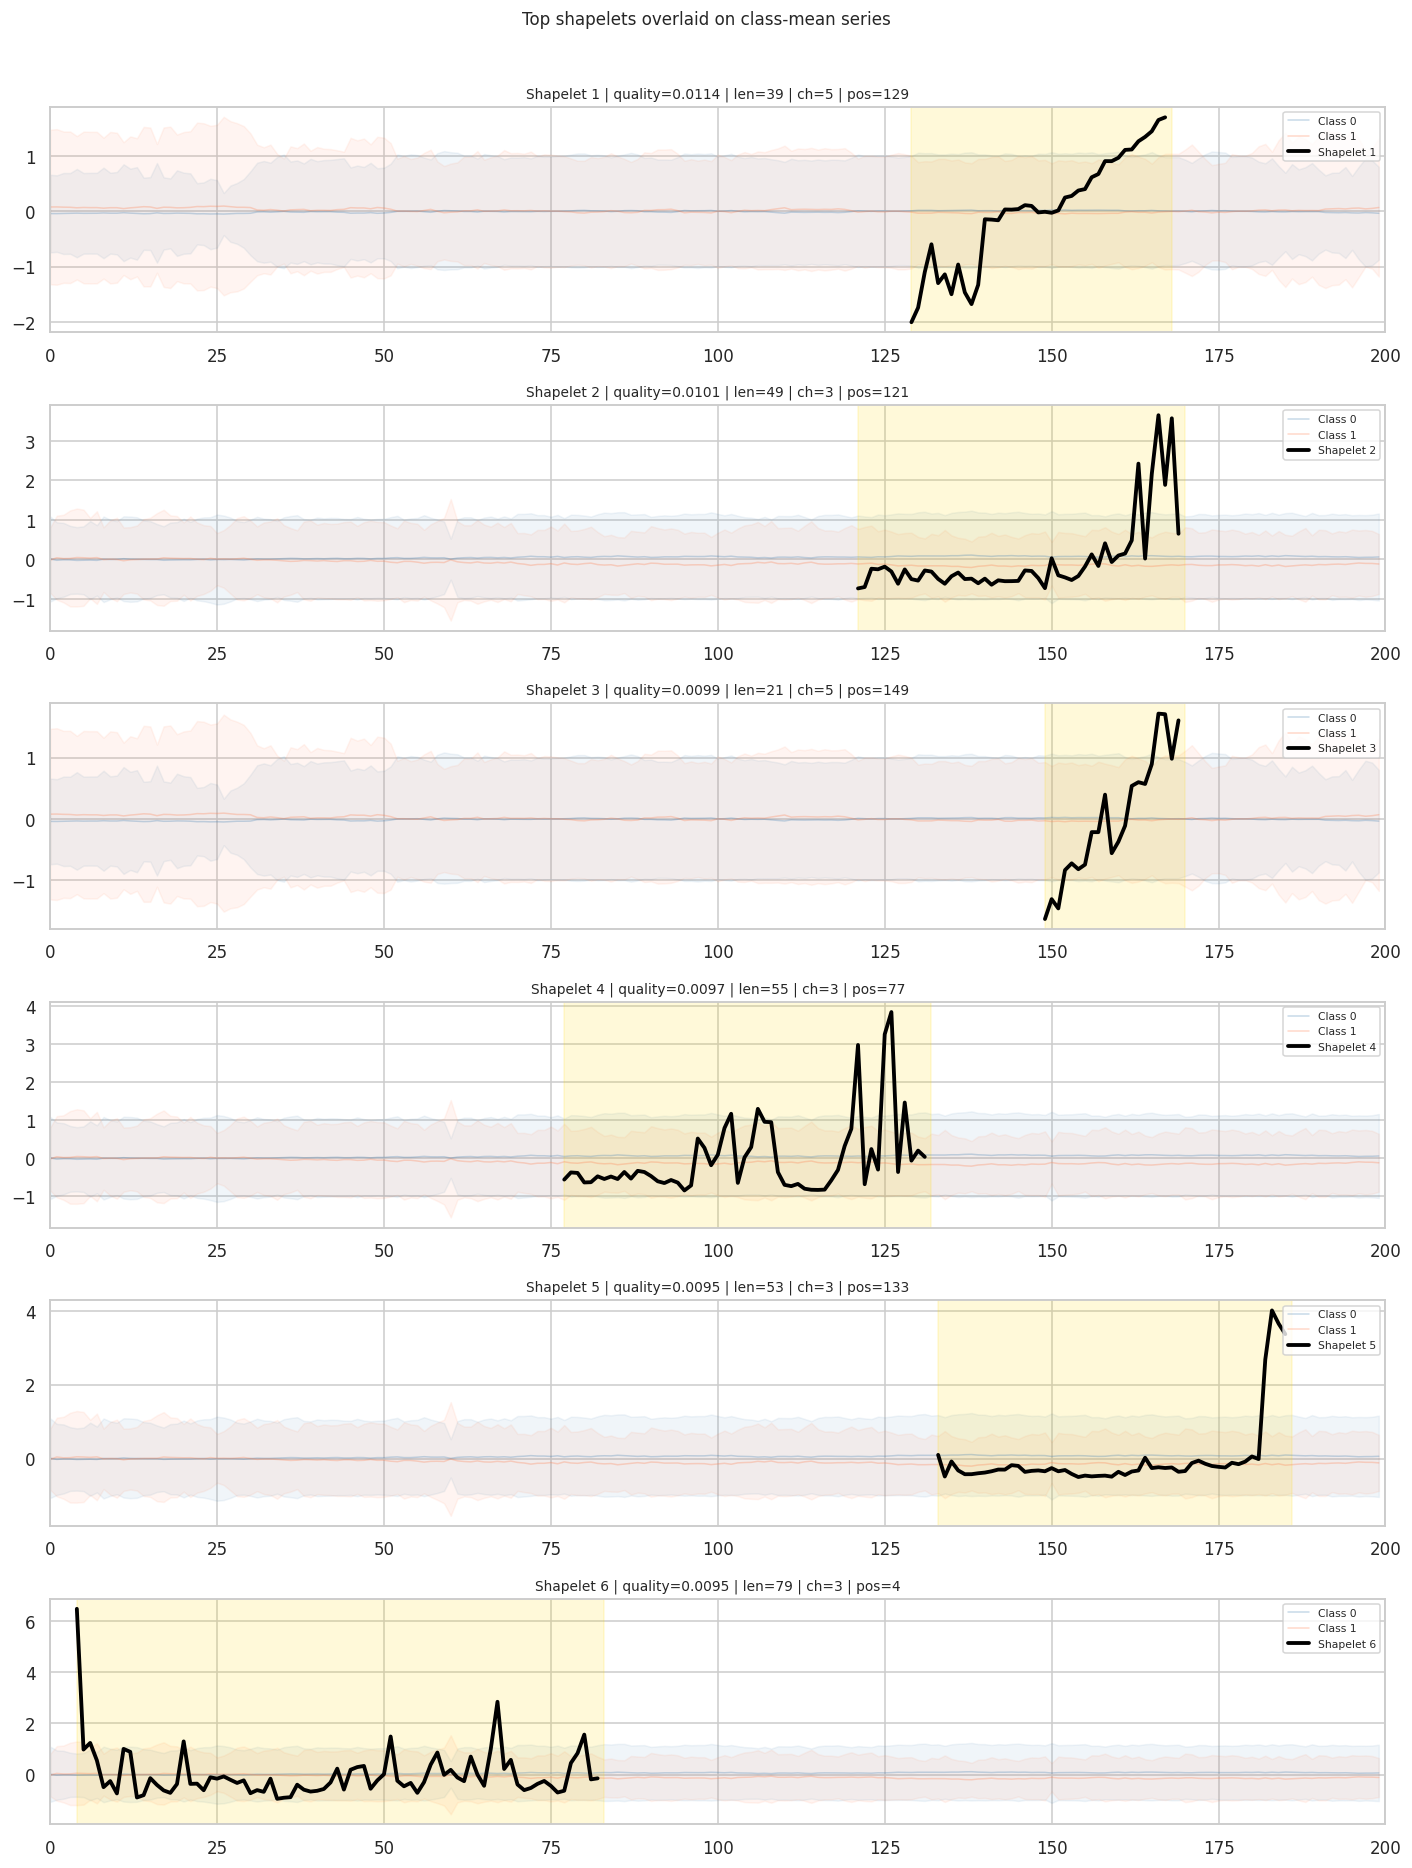

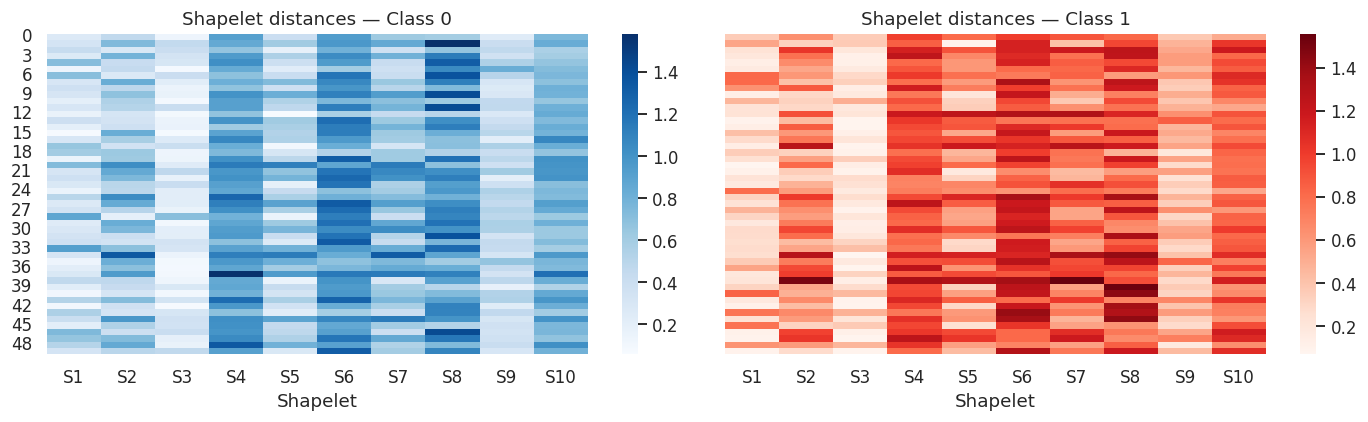

In [ ]:
sorted_sh = sorted(shapelets, key=lambda s: s[0], reverse=True)
N_SHOW = min(6, len(sorted_sh))

fig, axes = plt.subplots(N_SHOW, 1, figsize=(13, 2.8*N_SHOW), sharex=False)
if N_SHOW == 1: axes = [axes]

for idx, (ax, sh) in enumerate(zip(axes, sorted_sh[:N_SHOW])):
    quality  = float(sh[0])
    length   = int(sh[1])
    pos      = int(sh[2])
    ch       = int(sh[3])
    sv       = np.array(sh[6]).flatten()          # shapelet values (z-normalised)

    # Background: class-mean ± std for the raw channel (ch % C handles derivative channels)
    raw_ch = ch % C
    for cls, colour in zip([0, 1], ["steelblue", "coral"]):
        mask = y_train == cls
        mu   = Xtr_feat[mask, :, raw_ch].mean(0)
        sig  = Xtr_feat[mask, :, raw_ch].std(0)
        ax.plot(mu, color=colour, alpha=0.3, lw=1, label=f"Class {cls}")
        ax.fill_between(np.arange(T), mu-sig, mu+sig, color=colour, alpha=0.08)

    # Shapelet overlay
    t_sh = np.arange(pos, pos + len(sv))
    ax.plot(t_sh, sv, color="black", lw=2.5, label=f"Shapelet {idx+1}")
    ax.axvspan(pos, pos + len(sv), color="gold", alpha=0.15)
    ax.set_title(
        f"Shapelet {idx+1} | quality={quality:.4f} | len={length} | ch={ch} | pos={pos}",
        fontsize=9
    )
    ax.legend(fontsize=7, loc="upper right"); ax.set_xlim(0, T)

fig.suptitle("Top shapelets overlaid on class-mean series", fontsize=11, y=1.01)
plt.tight_layout(); plt.show()

# Distance heatmap
feat_arr = np.array(Xtr_shape)          # convert DataFrame → numpy
fig2, ax2s = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, cls, cmap in zip(ax2s, [0, 1], ["Blues", "Reds"]):
    idx_cls = np.where(y_train == cls)[0][:50]
    sns.heatmap(feat_arr[idx_cls, :10], ax=ax, cmap=cmap,
                xticklabels=[f"S{i+1}" for i in range(10)])
    ax.set_title(f"Shapelet distances — Class {cls}"); ax.set_xlabel("Shapelet")
plt.tight_layout(); plt.show()

### 10c — Shapelet + XGBoost Classifier

In [ ]:
n0, n1 = np.bincount(y_train)
spw = n0 / n1      # scale_pos_weight corrects class imbalance in XGBoost

xgb = XGBClassifier(
    n_estimators     = 400,
    max_depth        = 5,
    learning_rate    = 0.04,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = spw,
    eval_metric      = "logloss",
    random_state     = SEED,
    n_jobs           = -1,
)
t0 = time.time()
xgb.fit(np.array(Xtr_shape), y_train)
print(f"XGBoost fit in {time.time()-t0:.0f}s")

pred_shap  = xgb.predict(np.array(Xte_shape))
proba_shap = xgb.predict_proba(np.array(Xte_shape))[:, 1]
evaluate("Shapelet + XGBoost", y_test, pred_shap, proba_shap)

XGBoost fit in 5s


NameError: name 'evaluate' is not defined

In [ ]:
# ============================================================
# Shapelet + Random Forest
# ============================================================
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)
t0 = time.time()
rf.fit(Xtr_shape, y_train)
print(f"Random Forest fit in {time.time()-t0:.0f}s")

pred_rf = rf.predict(Xte_shape)
proba_rf = rf.predict_proba(Xte_shape)[:, 1]
evaluate("Shapelet + Random Forest", y_test, pred_rf, proba_rf)

In [ ]:
# ============================================================
# Shapelet + KNN (using shapelet distance features)
# ============================================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Use the shapelet feature matrix from earlier (Xtr_shape, Xte_shape)
# These are already 50-dimensional vectors (distances to each shapelet)

param_grid = {'n_neighbors': [3, 5, 7, 9, 11]}
knn_shape = GridSearchCV(
    KNeighborsClassifier(metric='euclidean', weights='distance'),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
t0 = time.time()
knn_shape.fit(Xtr_shape, y_train)
print(f"Shapelet KNN CV done in {time.time()-t0:.0f}s")
print(f"Best k = {knn_shape.best_params_['n_neighbors']}, CV F1 = {knn_shape.best_score_:.4f}")

pred_knn_shape = knn_shape.predict(Xte_shape)
# KNN doesn't give probabilities by default; we can use distance-weighted voting
# For ROC-AUC, we need probabilities – use predict_proba if available
try:
    proba_knn_shape = knn_shape.predict_proba(Xte_shape)[:, 1]
except:
    proba_knn_shape = None

evaluate("Shapelet + KNN", y_test, pred_knn_shape, proba_knn_shape)

## 11 — MiniROCKET

Applies 10 000 random convolutional kernels → PPV features → linear/boosted classifier.

In [ ]:
# MiniRocketMultivariate also expects (N, C, T)
Xtr_rk_in = np.transpose(Xtr_feat, (0, 2, 1))
Xte_rk_in = np.transpose(Xte_feat, (0, 2, 1))

rocket = MiniRocketMultivariate(num_kernels=10_000, random_state=SEED)
t0 = time.time()
rocket.fit(Xtr_rk_in)
Xtr_rk = np.array(rocket.transform(Xtr_rk_in))   # → numpy float32
Xte_rk = np.array(rocket.transform(Xte_rk_in))
print(f"ROCKET features: {Xtr_rk.shape}   [{time.time()-t0:.0f}s]")

### 11a — ROCKET + Ridge

In [ ]:
ros = RandomOverSampler(random_state=SEED)
Xr_rk, yr_rk = ros.fit_resample(Xtr_rk, y_train)

ridge = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
t0 = time.time()
ridge.fit(Xr_rk, yr_rk)
print(f"Ridge fit in {time.time()-t0:.0f}s  alpha={ridge.alpha_:.4g}")

pred_ridge  = ridge.predict(Xte_rk)
df_val      = ridge.decision_function(Xte_rk)
proba_ridge = 1 / (1 + np.exp(-df_val))     # sigmoid → probability
evaluate("MiniROCKET + Ridge", y_test, pred_ridge, proba_ridge)

### 11b — ROCKET + LightGBM

In [ ]:
lgb = LGBMClassifier(
    n_estimators     = 600,
    learning_rate    = 0.02,
    num_leaves       = 63,
    min_child_samples= 20,
    subsample        = 0.8,
    colsample_bytree = 0.5,
    class_weight     = "balanced",
    random_state     = SEED,
    n_jobs           = -1,
    verbose          = -1,
)
t0 = time.time()
lgb.fit(Xtr_rk, y_train)
print(f"LightGBM fit in {time.time()-t0:.0f}s")

pred_lgb  = lgb.predict(Xte_rk)
proba_lgb = lgb.predict_proba(Xte_rk)[:, 1]
evaluate("MiniROCKET + LightGBM", y_test, pred_lgb, proba_lgb)

## 12 — Final Comparison

In [ ]:
df_res = pd.DataFrame(RESULTS).sort_values("Macro F1", ascending=False).reset_index(drop=True)
df_res.index += 1
print(df_res.to_string())

# Bar chart
df_plot = pd.DataFrame(RESULTS).sort_values("Macro F1")
metrics = ["Macro F1", "Bal Acc", "ROC-AUC"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = plt.cm.tab10(np.linspace(0, 1, len(df_plot)))

for ax, metric in zip(axes, metrics):
    vals  = pd.to_numeric(df_plot[metric], errors="coerce").values
    names = df_plot["Model"].values
    valid = ~np.isnan(vals)
    bars  = ax.barh(names[valid], vals[valid], color=colors[valid], edgecolor="k")
    for bar, v in zip(bars, vals[valid]):
        ax.text(v + 0.005, bar.get_y() + bar.get_height()/2,
                f"{v:.3f}", va="center", fontsize=8)
    ax.set_xlim(0, 1.05)
    ax.set_title(metric, fontweight="bold")

plt.suptitle("Model Comparison", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

## 13 — Discussion

In [ ]:
best = pd.DataFrame(RESULTS).sort_values("Macro F1", ascending=False).iloc[0]

print(f"""
TASK
  Binary classification on 7-channel physiological TS (N=3355/953, T=200).
  Class imbalance ~2:1 — all models use oversampling or class_weight.

KNN
  Euclidean / Manhattan: fast flat-feature baseline.  Manhattan (L1) is
  more robust to artefact spikes because it does not square residuals.
  Both use distance-weighting and cross-validated k in {{3,5,7,9}}.

  DTW: elastic matching allows phase-shifted patterns to align.
  Sakoe-Chiba band (radius=5) prevents degenerate warpings and speeds
  computation. PAA compression (200→40) makes the O(T^2) DP tractable.

SHAPELETS
  RandomShapeletTransform samples 2000 candidates and retains the 50
  with highest F-stat quality.  The quality/length/channel plots above
  show which sensors carry the most discriminative local patterns.
  XGBoost with scale_pos_weight handles the class imbalance.

MINIROCKET
  10 000 random convolutional kernels → PPV features.  Ridge is the
  standard linear head (fast, strong regularisation).  LightGBM
  captures non-linear feature interactions.  ROCKET-family methods
  are state-of-the-art across UCR/UEA multivariate benchmarks.

Best model: {best['Model']}  (Macro F1 = {best['Macro F1']:.4f})
""")